# Phase 1 - Heart Disease Prediction

**Course:** SWE485 (Selected Topics in Software Engineering)  
**Phase:** 1 (Problem Understanding & Data Exploration)  
**Dataset:** Heart Disease Dataset (Kaggle)

This notebook covers:
- Introduction & Problem Statement
- Dataset Selection & Justification
- Initial Data Inspection
- Exploratory Data Analysis (with visualizations)
- Key Insights & Challenges
- Preprocessing Pipeline (with justifications)
- Preprocessed Dataset Ready for Modeling



## 1) Introduction & Problem Statement

Heart disease remains one of the leading causes of death worldwide, making early diagnosis essential for improving patient survival and reducing complications. Many cardiovascular conditions develop silently over time, meaning patients may not receive treatment until severe symptoms appear.
The objective of this project is to build a machine learning-based medical prediction system that classifies whether a patient is likely to have heart disease based on clinical and demographic measurements. Such a system can support early risk assessment and assist healthcare professionals in prioritizing further medical evaluation.
This project falls under the healthcare domain, and it aligns with the course goal of developing a supervised classification advice system during Phase 1.



## 2) Dataset Selection & Justification

**Source (Kaggle):** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

The goal of this dataset is to support medical risk prediction and binary classification, where the task is to determine whether a patient has heart disease based on clinical and demographic measurements. It is commonly used for developing supervised learning models for cardiovascular disease detection.

The dataset is structured in a tabular format and contains **1,025 patient records** with **13 medical features**, in addition to a binary target variable (`target`), where 0 indicates no heart disease and 1 indicates the presence of heart disease.

This dataset was selected because it is clinically relevant, well-structured, and meets Phase 1 requirements in terms of dataset size, feature complexity, and classification classes.

Additionally, the dataset demonstrates high quality and completeness, as it contains no missing values and provides a balanced distribution between the two target classes. These characteristics make it reliable for exploratory analysis and effective supervised learning model development.
OR -------------------------------------------------------------------
The selected dataset is intended to support medical risk prediction and binary classification tasks, where the objective is to determine whether a patient is likely to have heart disease based on clinical and demographic measurements. The dataset is widely used in cardiovascular research and machine learning applications due to its clear target definition and medically meaningful features.


The dataset is organized in a structured tabular format and contains  **1,025 patient records** with **13 clinical features**, in addition to a binary target variable (`target`), where 0 indicates the absence of heart disease and 1 indicates its presence. The available features capture multiple diagnostic aspects, making the dataset suitable for both predictive modeling and exploratory data analysis.
This dataset was selected because it is clinically relevant, well-structured, and meets the Phase 1 requirements in terms of dataset size, feature diversity, and classification suitability. Its tabular nature also makes it appropriate for applying a wide range of machine learning techniques, including supervised learning models and unsupervised exploratory methods in later phases.
During the initial inspection, the dataset appeared complete with no missing values and a relatively balanced distribution between the two target classes. These characteristics suggested that the dataset was suitable for exploratory data analysis and model development. However, deeper data quality assessment performed during the EDA phase revealed additional considerations, which are discussed in the`..................`

## 2) Dataset Selection & Justification
---------REEM: OR THIS I FEEL ITS SHORTER AND BREIF, tried to not make it about classfication only ----------

**Source (Kaggle):** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
This dataset supports binary classification tasks aimed at predicting the presence of heart disease using clinical and demographic features. It contains:
* **1,025 patient records** 
* **13 medical features**
* **one binary classification variable**

The dataset is organized in a structured tabular format and includes clinically meaningful variables that capture multiple diagnostic aspects of cardiovascular health. Its clear target definition and feature diversity make it well-suited for supervised learning models.
Beyond classification, the dataset is also suitable for clustering analysis and generative AI applications due to its structured nature and interpretable medical attributes. These characteristics allow for exploratory pattern discovery and potential synthetic data generation experiments.

The dataset was selected because it is clinically relevant, well-structured, and appropriate for Phase 1 requirements in terms of size, feature diversity, and modeling suitability. Additionally, the dataset contains no missing values and exhibits a relatively balanced distribution between target classes, making it reliable for exploratory data analysis and predictive modeling.

## 3) Features explanation

- **age**: Age of the patient.

- **sex**: Patient’s biological sex (0 = female, 1 = male).

- **cp (chest pain type)**: Type of chest pain  
  (0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic).

- **trestbps (resting blood pressure)**: Resting blood pressure measured in mm Hg.

- **chol (serum cholesterol)**: Serum cholesterol level measured in mg/dl.

- **fbs (fasting blood sugar > 120 mg/dl)**: Indicates whether fasting blood sugar exceeds 120 mg/dl  
  (1 = true, 0 = false).

- **restecg (resting electrocardiographic results)**: Resting ECG result  
  (0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy).

- **thalach (maximum heart rate achieved)**: Maximum heart rate recorded during exercise.

- **exang (exercise induced angina)**: Presence of exercise-induced angina  
  (1 = yes, 0 = no).

- **oldpeak**: ST depression induced by exercise relative to rest (numeric value).

- **slope**: Slope of the peak exercise ST segment  
  (0 = upsloping, 1 = flat, 2 = downsloping).

- **ca (number of major vessels)**: Number of major coronary vessels (0–3) detected by fluoroscopy.

- **thal**: Thalassemia test result  
  (0 = normal, 1 = fixed defect, 2 = reversible defect).

- **target**: binary classification label (0 = absence of heart disease, 1 = its presence)

## 4) Initial Data Inspection

In [16]:
import pandas as pd
import numpy as np

# Load dataset
DATA_PATH = "Dataset/HeartDiseaseClevlandDS.xlsx"   

df = pd.read_excel(DATA_PATH)

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [17]:
# Basic info: columns, dtypes, nulls (quick scan)
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nPreview of target distribution:")
print(df["target"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Preview of target distribution:
target
1    526
0    499
Name: count, dtype: 

## 5) Missing Values

In [18]:
missing_per_col = df.isnull().sum().sort_values(ascending=False)
total_missing = int(missing_per_col.sum())

print("Total missing values:", total_missing)
display(missing_per_col.to_frame("missing_count").head(20))

Total missing values: 0


,missing_count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


The dataset was successfully loaded in Python using Pandas.
Initial inspection confirmed:
1,025 observations
14 columns (13 features + target)
No missing values across all columns
The dataset includes both numerical measurements and encoded categorical clinical attributes.

## 6) Duplicate Data 

In [19]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


There were 723 duplicate row, so we remove them before performing exploratory data analysis (EDA) to avoid biased statistical results. 

In [20]:
non_duplicate_df=df.drop_duplicates()
non_duplicate_df[non_duplicate_df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


## 7) Correlation Analysis

We computed correlations between numerical features and presented them in a correlation table to verify the correctness of the target mapping and to identify strongly related variables and potential predictive signals for modeling.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

corr = non_duplicate_df.select_dtypes(include=[np.number]).corr()


# Show top correlations with the target (if target is numeric 0/1)
if "target" in corr.columns:
    target_corr = corr["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)
    print("Top correlations with target (by absolute value):")
    display(target_corr.to_frame("corr_with_target"))

Top correlations with target (by absolute value):


,corr_with_target
exang,-0.435601
cp,0.432080
oldpeak,-0.429146
thalach,0.419955
ca,-0.408992
slope,0.343940
thal,-0.343101
sex,-0.283609
age,-0.221476
trestbps,-0.146269


### 7.1) backwards mapping fixed
The correlation analysis table revealed illogical relationships between several features and the target variable. For example, the initial mapping suggested that lower cholesterol levels were associated with a higher probability of heart disease, which contradicts established medical evidence reported by the [American Heart Association](https://www.heart.org/en/health-topics/cholesterol), stating that high cholesterol is one of the major controllable risk factors for coronary heart disease, heart attack, and strokes.

Additionally, multiple features showed inverse (negative) correlations, indicating a possible mislabeling between diseased and non-diseased patients. Based on these observations, the backward mapping was corrected, and the target variable was redefined as *IsHeartDisease* to ensure clear and medically consistent classification.

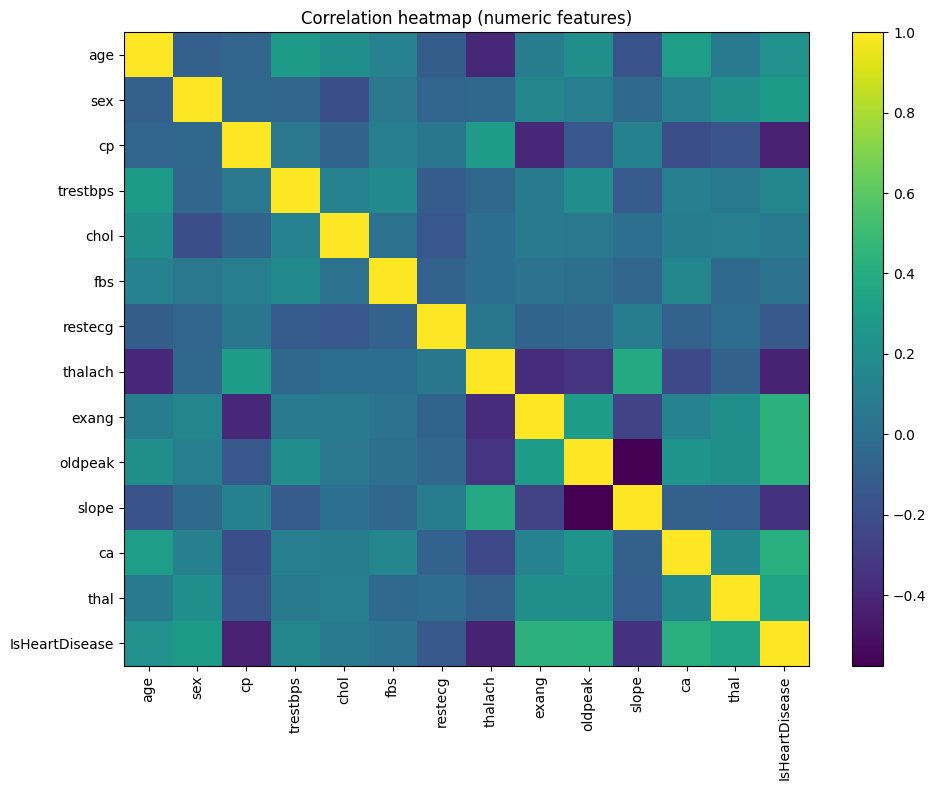

Top correlations with IsHeartDisease:


,corr_with_IsHeartDisease
exang,0.435601
cp,-0.432080
oldpeak,0.429146
thalach,-0.419955
ca,0.408992
slope,-0.343940
thal,0.343101
sex,0.283609
age,0.221476
trestbps,0.146269


In [22]:
import numpy as np

CorrectMapping_df = non_duplicate_df.copy()

# Map target: 0 = disease, 1 = no disease  →  IsHeartDisease: 1 = disease, 0 = no disease
CorrectMapping_df["IsHeartDisease"] = (CorrectMapping_df["target"] == 0).astype(int)

# drop old target columns to avoid confusion
CorrectMapping_df.drop(columns=["target"], inplace=True)

# validate correct correlations with isHeaIsHeartDisease clasification attribute
corr = CorrectMapping_df.select_dtypes(include=[np.number]).corr()
corr_features = corr.drop(index="IsHeartDisease", columns="IsHeartDisease")

# Show top correlations
target_corr = (
    CorrectMapping_df
    .select_dtypes(include=[np.number])
    .corr()["IsHeartDisease"]
    .drop("IsHeartDisease")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

print("Top correlations with IsHeartDisease:")
display(target_corr.to_frame("corr_with_IsHeartDisease"))

### 7.2) Visualization of Strongly Correlated Features
Focusing on continuous variables that show a strong relationship with the IsHeartDisease variable, we can better understand which clinical factors contribute most to heart disease prediction. Visualizing these relationships helps highlight meaningful patterns.

C:\Users\reemk\AppData\Local\Temp\ipykernel_33964\3143414584.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('bin')['IsHeartDisease']


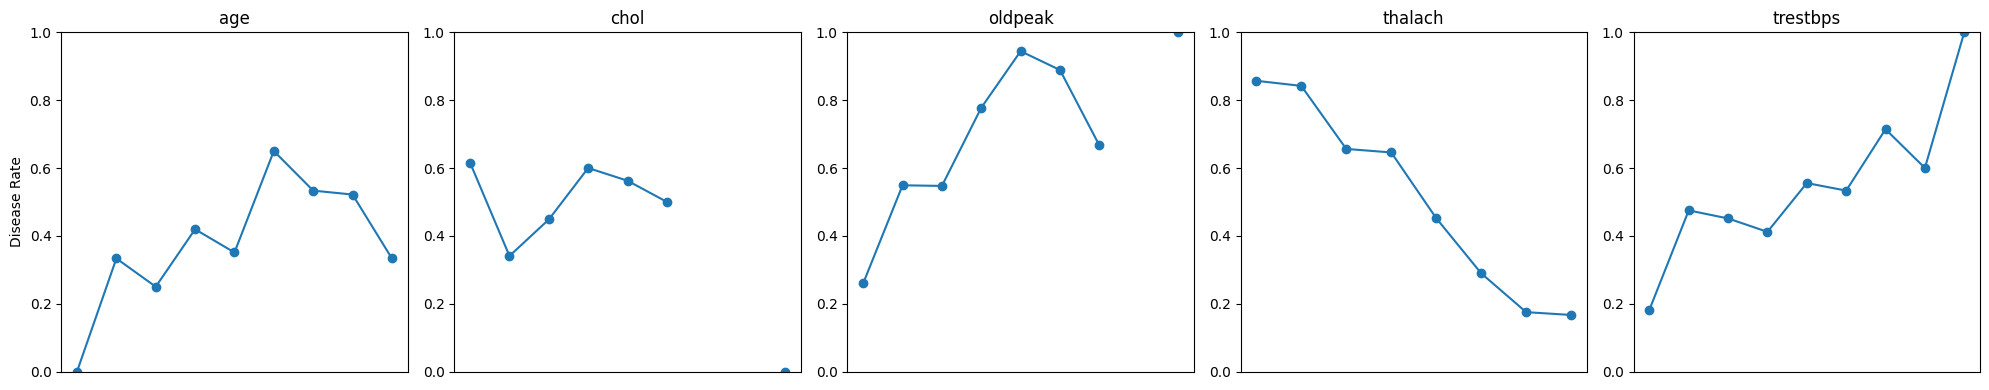

In [85]:
continuous_cols = ['age', 'chol', 'oldpeak', 'thalach', 'trestbps']

plt.figure(figsize=(20, 4))

for i, feature in enumerate(continuous_cols, 1):
    ax = plt.subplot(1, 5, i)

    # Create bins
    bins = np.linspace(
        CorrectMapping_df[feature].min(),
        CorrectMapping_df[feature].max(),
        10
    )

    CorrectMapping_df['bin'] = pd.cut(
        CorrectMapping_df[feature],
        bins=bins
    )

    # Compute mean disease rate per bin
    grouped = (
        CorrectMapping_df
        .groupby('bin')['IsHeartDisease']
        .mean()
    )

    # Plot
    ax.plot(grouped.values, marker='o')
    ax.set_title(feature)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_ylabel("Disease Rate" if i == 1 else "")

plt.tight_layout()
plt.show()

A binned probability plot was used to examine how the risk of heart disease changes as each continuous feature increases. the feature values were divided into intervals, and the average disease rate was calculated for each group. This makes it easier to see whether there is a clear increasing, decreasing, or flat trend between the feature and heart disease.

,Before Scaling,After Scaling
0,52,-0.267966
1,53,-0.157260
2,70,1.724733
3,61,0.728383
4,62,0.839089


Mean: -2.676299211679185e-16
Std: 1.0016597521794577


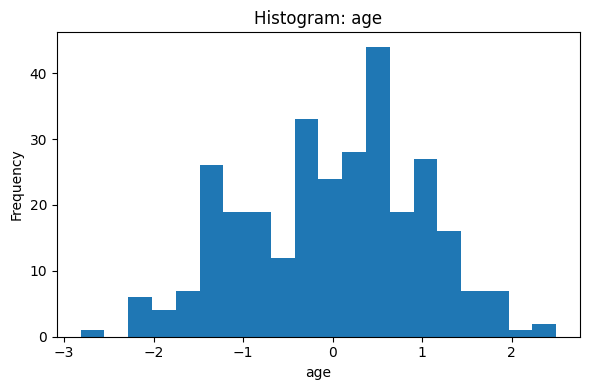

In [ ]:
from sklearn.preprocessing import StandardScaler

PreProcessd_df = CorrectMapping_df.copy()

age_before=CorrectMapping_df['age']
scaler = StandardScaler()
PreProcessd_df['age'] = scaler.fit_transform(PreProcessd_df[['age']])

#prove the success of the normalization
age_comparison_table = pd.concat(
    [age_before.head(), PreProcessd_df['age'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(age_comparison_table)

print("Mean:", PreProcessd_df['age'].mean())
print("Std:", PreProcessd_df['age'].std())

plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['age'].dropna(), bins=20)
plt.title(f"Histogram: {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 8) Targeted Class Distribution

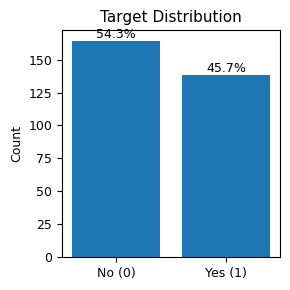

In [54]:
import matplotlib.pyplot as plt

counts = CorrectMapping_df["IsHeartDisease"].value_counts().sort_index()
labels = ["No (0)", "Yes (1)"]

plt.figure(figsize=(3,3))

bars = plt.bar(labels, counts.values)

total = counts.sum()
for i, bar in enumerate(bars):
    percentage = counts.values[i] / total * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Target Distribution", fontsize=11)
plt.ylabel("Count", fontsize=9)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

## 9) Descriptive Statistics

We compute summary statistics (mean, std, min/max, quartiles) to understand the ranges and variability of numeric features.


In [55]:
# Descriptive statistics for numeric columns
CorrectMapping_df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


## 10) Feature Distributions (Histograms)

Histograms show how each numeric feature is distributed across the dataset.


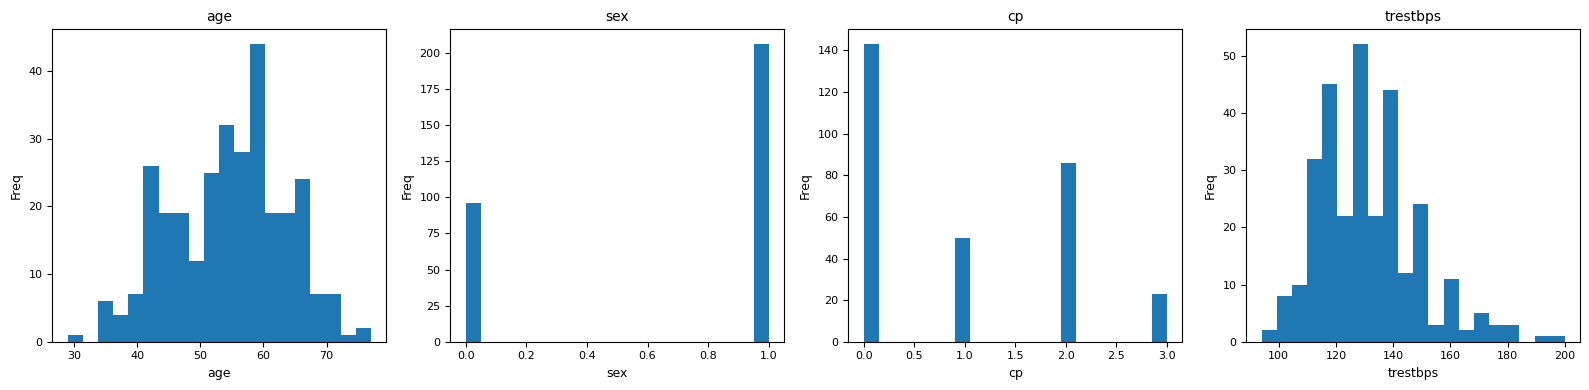

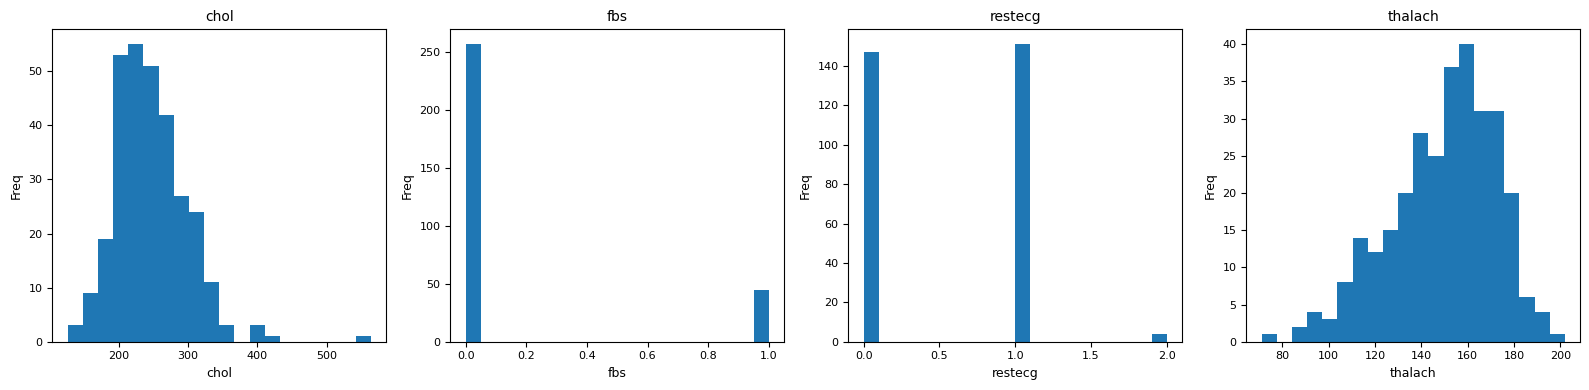

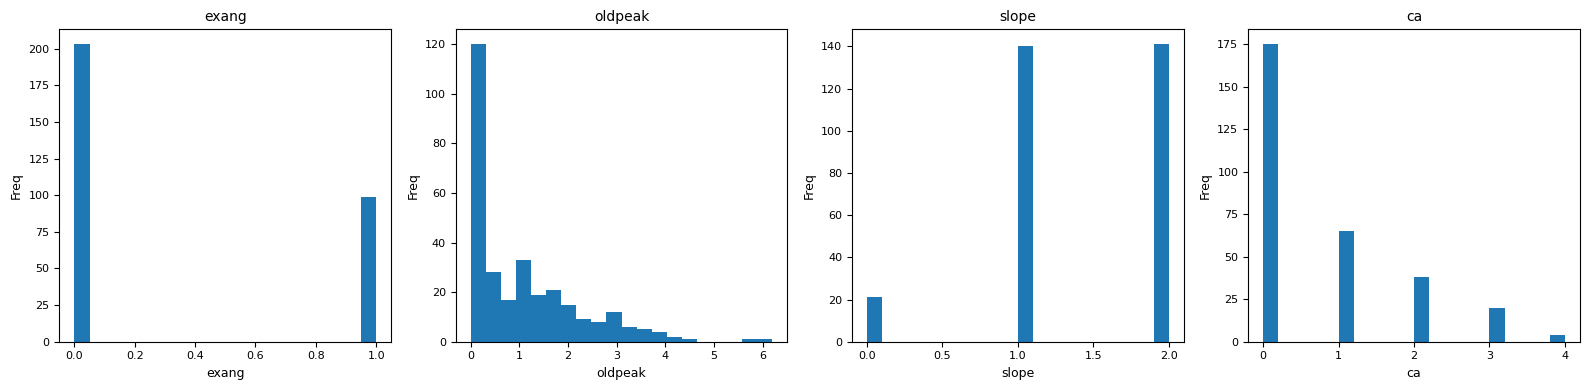

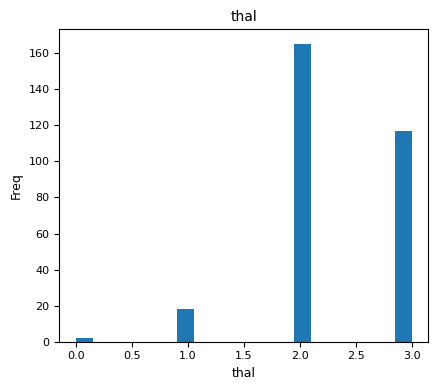

In [56]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = CorrectMapping_df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target column
numeric_feature_cols = [c for c in numeric_cols if c != "IsHeartDisease"]

for i in range(0, len(numeric_feature_cols), 4):
    cols_subset = numeric_feature_cols[i:i+4]
    
    plt.figure(figsize=(16, 4))  # 4 plots per row
    
    for j, col in enumerate(cols_subset, 1):
        plt.subplot(1, 4, j)
        plt.hist(CorrectMapping_df[col].dropna(), bins=20)
        plt.title(col, fontsize=10)
        plt.xlabel(col, fontsize=9)
        plt.ylabel("Freq", fontsize=9)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

## 11) Outliers & Spread (Box Plots)

Box plots help detect outliers and compare the spread of each numeric feature.


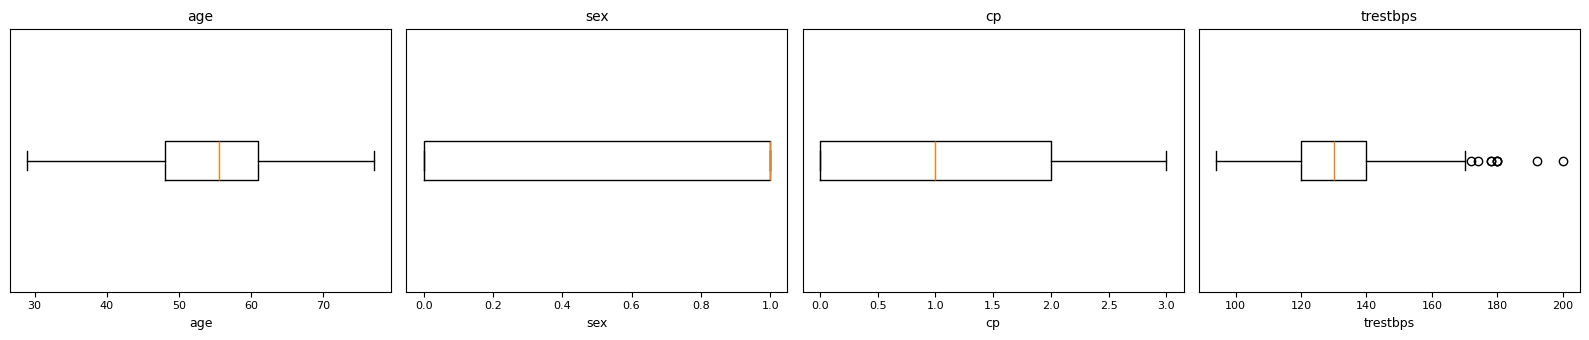

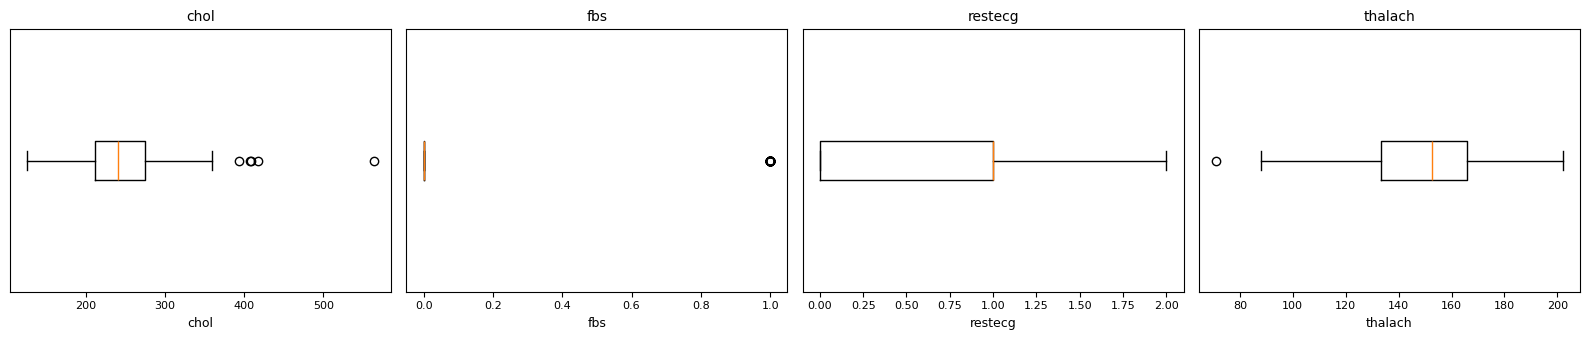

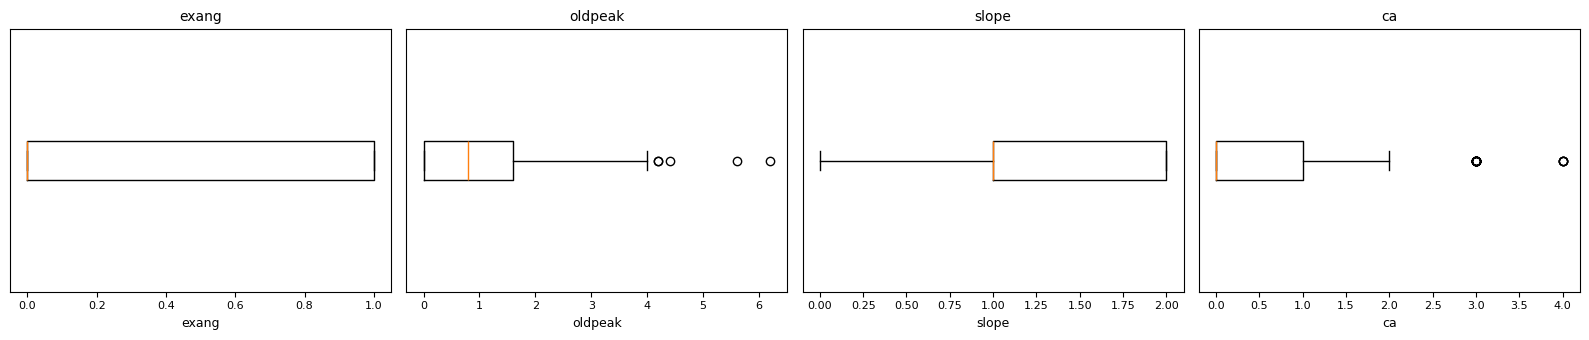

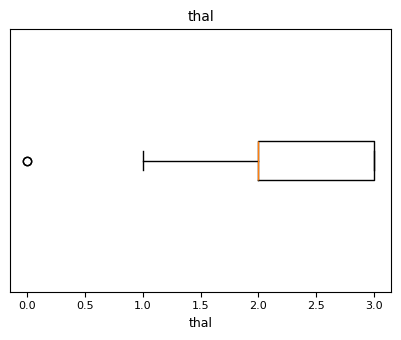

In [57]:
import matplotlib.pyplot as plt

numeric_feature_cols = [c for c in numeric_feature_cols if c != "IsHeartDisease"]

for i in range(0, len(numeric_feature_cols), 4):
    cols_subset = numeric_feature_cols[i:i+4]
    
    plt.figure(figsize=(16, 3.5))
    
    for j, col in enumerate(cols_subset, 1):
        plt.subplot(1, 4, j)
        plt.boxplot(CorrectMapping_df[col].dropna(), vert=False)
        plt.title(col, fontsize=10)
        plt.xlabel(col, fontsize=9)
        plt.yticks([])
        plt.xticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

## 12) correlation between features (Scatter plots)
Scatter plots were generated for continuous numerical features to explore potential linear and non-linear relationships. Categorical variables were excluded from this analysis since their encoded numeric values do not represent true continuous scales and may distort correlation interpretation.

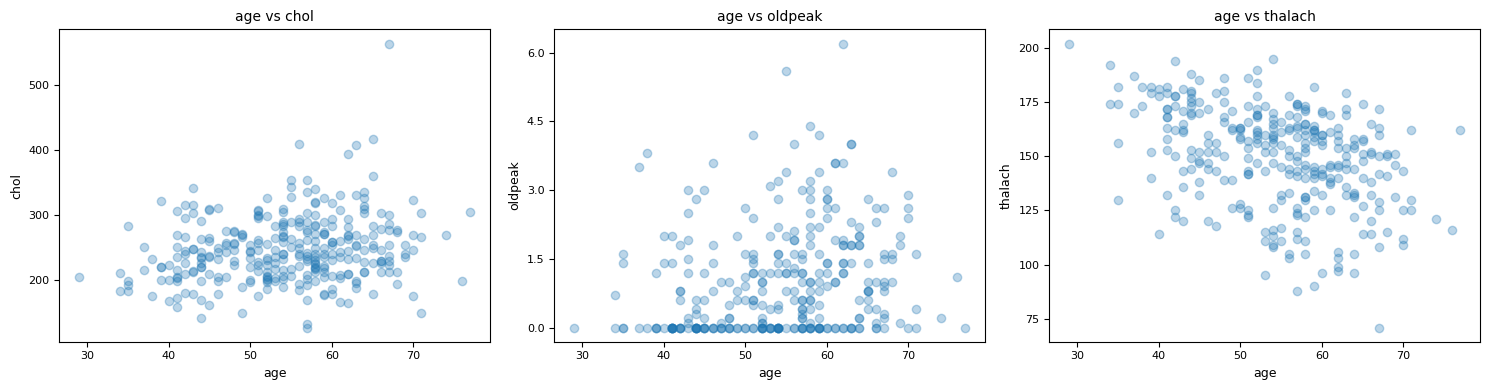

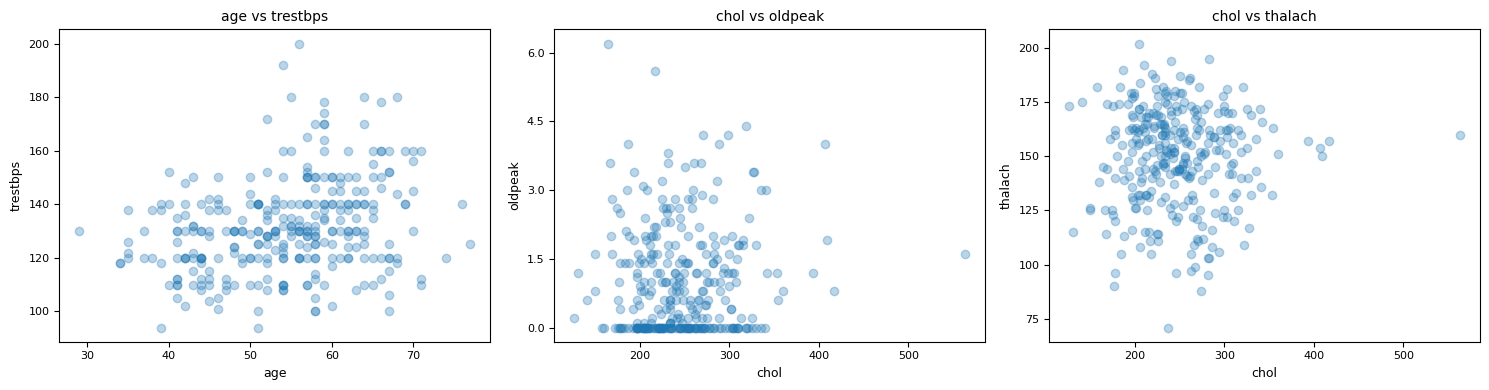

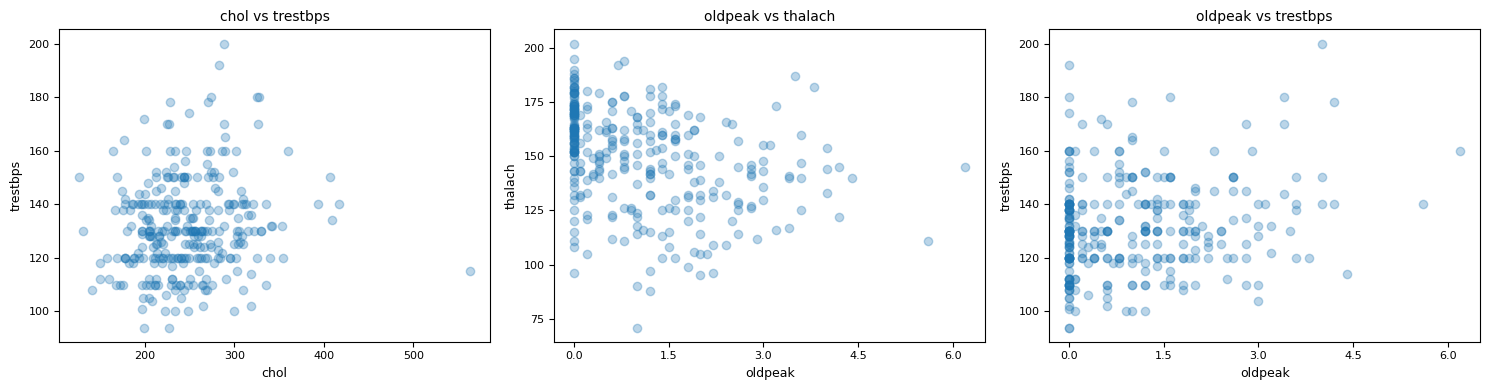

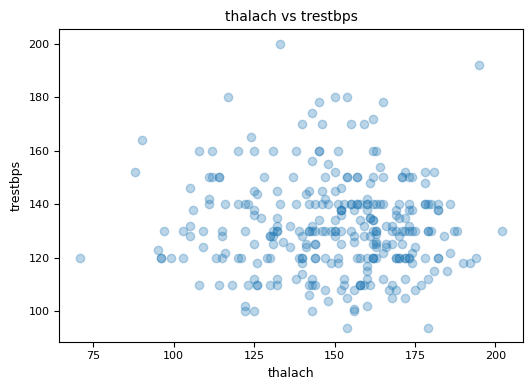

In [58]:
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.ticker import MaxNLocator

continuous_cols = ['age', 'chol', 'oldpeak', 'thalach', 'trestbps']

pairs = list(combinations(continuous_cols, 2))

for i in range(0, len(pairs), 3):
    subset = pairs[i:i+3]
    
    plt.figure(figsize=(15, 4))
    
    for j, (x_col, y_col) in enumerate(subset, 1):
        plt.subplot(1, 3, j)
        plt.scatter(
            CorrectMapping_df[x_col],
            CorrectMapping_df[y_col],
            alpha=0.3
        )
        
        ax = plt.gca()
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        
        plt.xlabel(x_col, fontsize=9)
        plt.ylabel(y_col, fontsize=9)
        plt.title(f"{x_col} vs {y_col}", fontsize=10)
        plt.xticks(fontsize=8)
        plt.yticks(fontsize=8)

    plt.tight_layout()
    plt.show()

## 13) Feature vs Target (Group Comparison)

We compare numeric feature means across the two IsHeartDisease classes (0 vs 1) to get an initial sense of which features differ between classes.

In [59]:
group_means = CorrectMapping_df.groupby("IsHeartDisease")[numeric_feature_cols].mean().T
group_means.columns = ["mean_IsHeartDisease_0", "mean_IsHeartDisease_1"]
group_means["diff_(1-0)"] = group_means["mean_IsHeartDisease_1"] - group_means["mean_IsHeartDisease_0"]
group_means.sort_values(by="diff_(1-0)", key=lambda s: s.abs(), ascending=False).head(20)

,mean_IsHeartDisease_0,mean_IsHeartDisease_1,diff_(1-0)
thalach,158.378049,139.101449,-19.276600
chol,242.640244,251.086957,8.446713
trestbps,129.250000,134.398551,5.148551
age,52.585366,56.601449,4.016083
oldpeak,0.586585,1.585507,0.998922
cp,1.371951,0.478261,-0.893690
ca,0.341463,1.166667,0.825203
slope,1.591463,1.166667,-0.424797
thal,2.121951,2.543478,0.421527
exang,0.140244,0.550725,0.410481


## 14) Key Insights & Challenges

Key findings from the EDA include:
- The dataset contains no missing values, indicating high completeness.
- Target classes are relatively balanced (526 vs 499), reducing class imbalance concerns.
- Several features show strong relationships with heart disease outcomes, particularly oldpeak, exang, chest pain type, and maximum heart rate.
- A potential challenge is the presence of outliers in some clinical measurements, which may require scaling or robust preprocessing in the next phase.

## 15) Data Preprocessing






### 15.1 Normalization 

Normalization is the process of transforming continuous numerical features into a comparable scale. 
Without feature scaling, machine learning models may assign excessive importance to features with wider numerical ranges while underestimating features with smaller ranges.

Multiple normalization techniques can be applied depending on the feature data distribution as well as the presence of outliers. 
The following table summarizes the normalization techniques used in this study and the situations in which each technique is most appropriate.

| Normalization Technique | Formula | Distribution Type | Outlier Sensitivity |
| :--- | :---: | :---: | :---: |
| Z-score Standardization | $x_{scaled}=\frac{x-\mu}{\sigma}$ | Approximately normal or symmetric distribution | Sensitive |
| Log Transformation | $x_{scaled}= \log(x)$ | Right-skewed distribution | Reduces effect of extreme values |
| RobustScaler | $x_{scaled}=\frac{x-\text{Median}(x)}{Q_{3}-Q_{1}}$ | Approximately normal or Moderate skew with outliers | Low sensitivity |
| Linear scaling| $x_{scaled}=\frac{x-x_{min}}{x_{max}-x_{min}}$| Approximately uniform distribution|Sensitive|

The feature distribution type can be visually assessed using histogram diagrams, while the existence of outliers can be identified through boxplot diagrams. 
However, visual inspection alone may be misleading; therefore, statistical measurements such as the skewness coefficient were also calculated using the `skew()` function to quantitatively evaluate distribution symmetry.
The following table illustrate the skewness coefficient ranges:

| Skewness coefficient range |Distribution Type |
| :--- | :---: |
|between -0.5 and 0.5 but not 0 |approximately normal|
|between -1 and -0.5 or between 0.5 and 1|moderately skewed|
|grater than 1 or less than -1 |highly skewed|



#### 15.1.1 Age Feature Normalization

##### - Distribution Analysis

Based on the previous Age histogram and boxplot diagrams:

- The histogram shows an approximately symmetric distribution.
- The boxplot shows balanced whiskers and doesn't show any outliers.

To quantitatively prove the distribution type, we will calculate the skewness coefficient for the age feature.

In [60]:
print("The skewness coefficient of Age:", CorrectMapping_df['age'].skew())

The skewness coefficient of Age: -0.20374327959596905


##### - Interpretation

The skewness coefficient of the age is within the approximately symmetric distribution range (-0.5 to 0.5).
Since there are no outliers and the distribution is approximately symmetric, we will use Z-score standardization.

,Before Scaling,After Scaling
0,52,-0.267966
1,53,-0.157260
2,70,1.724733
3,61,0.728383
4,62,0.839089


Mean: -2.676299211679185e-16
Std: 1.0016597521794577


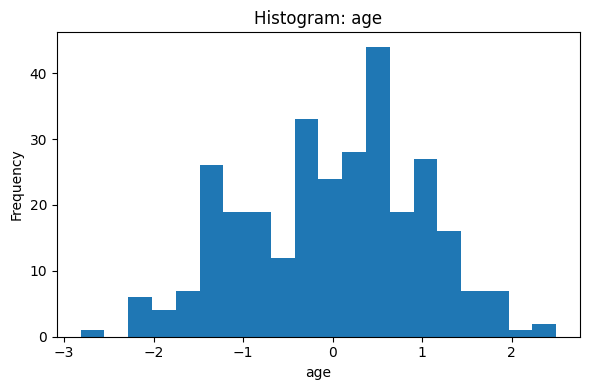

In [63]:
from sklearn.preprocessing import StandardScaler

PreProcessd_df = CorrectMapping_df.copy()

age_before=CorrectMapping_df['age']
scaler = StandardScaler()
PreProcessd_df['age'] = scaler.fit_transform(PreProcessd_df[['age']])

#prove the success of the normalization
age_comparison_table = pd.concat(
    [age_before.head(), PreProcessd_df['age'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(age_comparison_table)

print("Mean:", PreProcessd_df['age'].mean())
print("Std:", PreProcessd_df['age'].std())

plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['age'].dropna(), bins=20)
plt.title(f"Histogram: {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 15.1.2 Trestbps Feature Normalization

##### - Distribution Analysis

Based on the previous Trestbps histogram and boxplot diagrams:

- The histogram shows a positive skewness.
- The boxplot contains several outliers.

To quantitatively prove these observations, we will calculate the skewness coefficient for the trestbps feature.

In [64]:
print("The skewness coefficient of trestbps:", PreProcessd_df['trestbps'].skew())

The skewness coefficient of trestbps: 0.7165414326647316


##### - Interpretation

The skewness coefficient of the trestbps is within the moderate positive skewness range (0.5 to 1).
Since there are outliers and the skewness is not high, the RobustScaler was selected as a more appropriate normalization technique.

,Before Scaling,After Scaling
0,125,-0.25
1,140,0.50
2,145,0.75
3,148,0.90
4,138,0.40


Median: 0.0
Q1: -0.5
Q3: 0.5


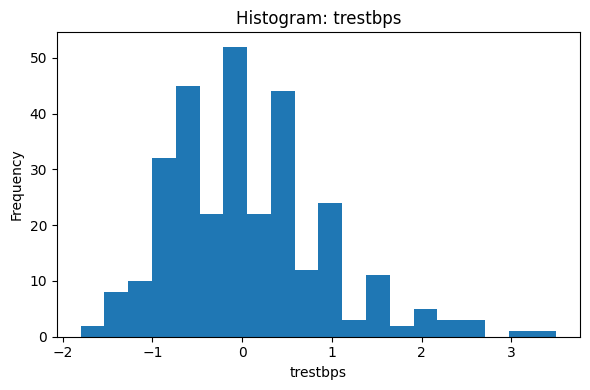

In [65]:
from sklearn.preprocessing import RobustScaler

trestbps_before=PreProcessd_df['trestbps'].copy()

scaler = RobustScaler()

PreProcessd_df['trestbps'] = scaler.fit_transform(PreProcessd_df[['trestbps']])


#prove the success of the normalization 
trestbps_comparison_table = pd.concat(
    [trestbps_before.head(), PreProcessd_df['trestbps'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(trestbps_comparison_table)

print("Median:", PreProcessd_df['trestbps'].median())
print("Q1:", PreProcessd_df['trestbps'].quantile(0.25))
print("Q3:", PreProcessd_df['trestbps'].quantile(0.75))

plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['trestbps'].dropna(), bins=20)
plt.title(f"Histogram: {'trestbps'}")
plt.xlabel('trestbps')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 15.1.3 Thalach Feature Normalization

##### -Distribution Analysis

Based on the previous Thalach histogram and boxplot diagrams:

- The histogram shows an approximately normal distribution.
- The boxplot indicates balanced whiskers with only one outlier.

To quantitatively prove these observations, we will calculate the skewness coefficient for the thalach feature.

In [66]:
print("The skewness coefficient of Cholesterol:", PreProcessd_df['thalach'].skew())

The skewness coefficient of Cholesterol: -0.5326712468229613


##### - Interpretation

The skewness coefficient of the thalach is within the moderate negative skewness range (-0.5 to -1).

Since the outliers and the asymmetry are slight and insignificant, they will not affect the normalization. Therefore, we will use the Z-score standardization.

,Before Scaling,After Scaling
0,168,0.806035
1,155,0.237495
2,125,-1.074521
3,161,0.499898
4,106,-1.905464


Mean: -5.323188541911346e-16
Std: 1.0016597521794577


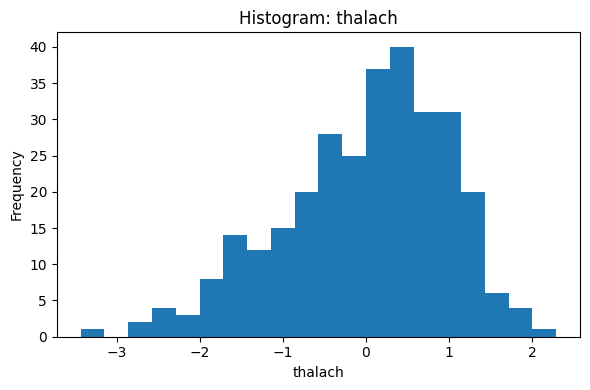

In [67]:
from sklearn.preprocessing import StandardScaler

thalach_before=PreProcessd_df['thalach'].copy()

scaler = StandardScaler()
PreProcessd_df['thalach'] = scaler.fit_transform(PreProcessd_df[['thalach']])

#prove the success of the normalization 
thalach_comparison_table = pd.concat(
    [thalach_before.head(), PreProcessd_df['thalach'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(thalach_comparison_table)

print("Mean:", PreProcessd_df['thalach'].mean())
print("Std:", PreProcessd_df['thalach'].std())


plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['thalach'].dropna(), bins=20)
plt.title(f"Histogram: {'thalach'}")
plt.xlabel('thalach')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### 15.1.4 Oldpeak Feature Normalization

##### -Distribution Analysis

Based on the previous Oldpeak histogram and boxplot diagrams:

- The histogram shows a positive skewness distribution with a large values concentration near zero.
- The boxplot has several outliers beyond the upper whisker.

To quantitatively prove these observations, we will calculate the skewness coefficient for the oldpeak feature.

In [68]:
print("The skewness coefficient of Cholesterol:", PreProcessd_df['oldpeak'].skew())

The skewness coefficient of Cholesterol: 1.266172720910219


##### -Interpretation

The skewness coefficient of the oldpeak is larger than 1, indicating strong positive skewness.

The feature contains several outliers, and both the histogram and the skewness coefficient show a strong right skewness. However, since these values may represent important clinically cases, removing them may result in the loss of important medical information. Therefore, a logarithmic transformation was applied to reduce skewness and compress large values before applying Z-score standardization.

,Before Scaling,After Scaling
0,1.0,0.231826
1,3.1,1.603568
2,2.6,1.355045
3,0.0,-1.092729
4,1.9,0.941858


Mean: -1.0587557320928645e-16
Std: 1.0016597521794577
The skewness coefficient of oldpeak after the normalization: 0.3919464030433015


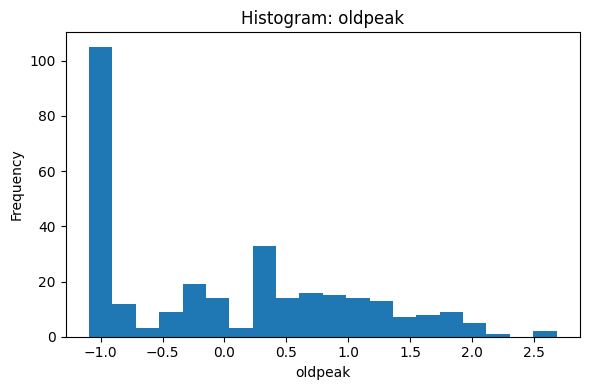

In [69]:
import numpy as np


oldpeak_before = PreProcessd_df['oldpeak'].copy()

PreProcessd_df['oldpeak'] = np.log1p(PreProcessd_df['oldpeak'])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

PreProcessd_df['oldpeak'] = scaler.fit_transform(PreProcessd_df[['oldpeak']])


#prove the success of the normalization 
oldpeak_comparison_table = pd.concat(
    [oldpeak_before.head(), PreProcessd_df['oldpeak'].head()],
    axis=1,
    keys=['Before Scaling', 'After Scaling']
)
display(oldpeak_comparison_table)

print("Mean:", PreProcessd_df['oldpeak'].mean())
print("Std:", PreProcessd_df['oldpeak'].std())
print("The skewness coefficient of oldpeak after the normalization:", PreProcessd_df['oldpeak'].skew())


plt.figure(figsize=(6,4))
plt.hist(PreProcessd_df['oldpeak'].dropna(), bins=20)
plt.title(f"Histogram: {'oldpeak'}")
plt.xlabel('oldpeak')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 15.2 Discretization
Discretization was not applied to most continuous variables to preserve numerical precision and the gradual nature of cardiovascular risk. However, cholesterol was discretized using established clinical thresholds, as cardiovascular risk is assessed based on risk categories (e.g., normal, borderline high, and high) rather than precise numeric values. As shown in Figure 1, the presence of extreme cholesterol values further supports discretization to improve interpretability and reduce their influence.

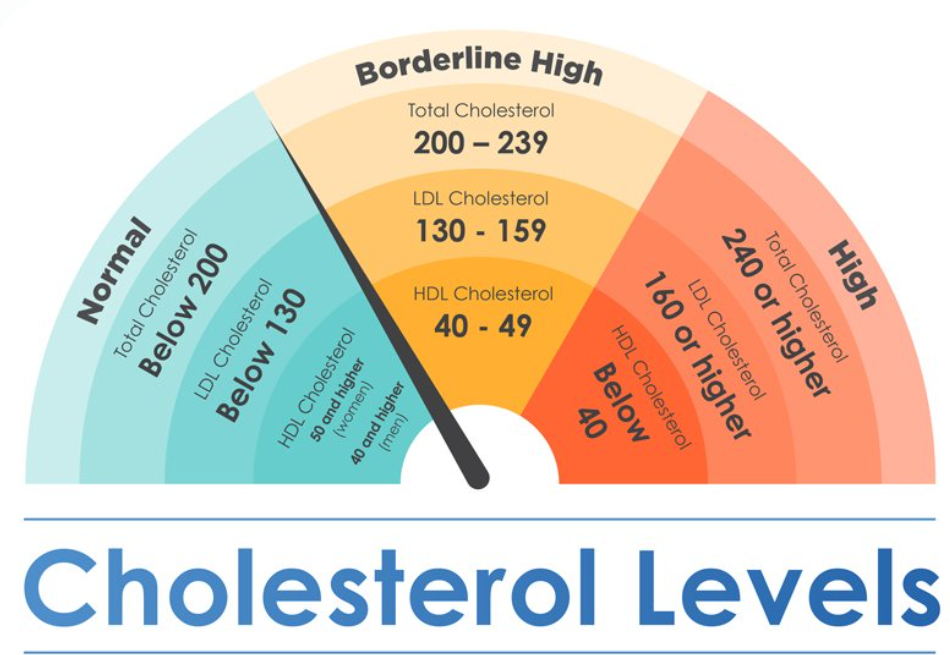

**Figure 1.** Distribution of cholesterol values showing the presence of clinically distinct risk ranges and extreme values. [Source: Modern Heart and Vascular (2024)](https://www.modernheartandvascular.com/high-cholesterol-and-heart-disease/)

In [70]:
from IPython.display import Image, display, Markdown

display(Image(filename="images/CholesterolMeasure.png", width=450))

display(Markdown(
    "**Figure 1.** Distribution of cholesterol values showing the presence of clinically distinct risk ranges and extreme values. "
    "[Source: Modern Heart and Vascular (2024)](https://www.modernheartandvascular.com/high-cholesterol-and-heart-disease/)"
))

In [71]:
import numpy as np
import pandas as pd

# Discretize cholesterol into clinically defined risk categories
chol_bins = [0, 200, 240, np.inf]
chol_labels = ['Normal', 'Borderline High', 'High']

PreProcessd_df['chol_category'] = pd.cut(
    PreProcessd_df['chol'],
    bins=chol_bins,
    labels=chol_labels,
    right=False
)

# Cholesterol risk category thresholds (clinical reference)
chol_mapping = pd.DataFrame({
    'Cholesterol Range (mg/dL)': ['< 200', '200–239', '≥ 240'],
    'Risk Category': chol_labels
})

# Distribution of cholesterol categories in the dataset
chol_distribution = (
    PreProcessd_df['chol_category']
    .value_counts()
    .rename_axis('Cholesterol Category')
    .reset_index(name='Number of Patients')
)

display(chol_mapping)
display(chol_distribution)

# Remove original cholesterol values to avoid redundant representation
PreProcessd_df.drop(columns=['chol'], inplace=True)

,Cholesterol Range (mg/dL),Risk Category
0,< 200,Normal
1,200–239,Borderline High
2,≥ 240,High


,Cholesterol Category,Number of Patients
0,High,155
1,Borderline High,98
2,Normal,49


### 15.3 Encoding
Categorical variables (cp, restecg, slope, ca, thal, and the discretized cholesterol category) were encoded using one-hot encoding because their numerical values represent distinct medical categories rather than ordered or equally spaced quantities. Applying one-hot encoding prevents the models from assuming artificial linear ordering or equal distances between categories and allows them to learn the effect of each category on the classification outcome directly from the data. Binary variables (sex, fbs, and exang) were retained in their original 0/1 format, as this representation is already suitable for classification models.

In [72]:
import pandas as pd

# Nominal and discretized categorical variables to encode
categorical_vars = ['cp', 'restecg', 'slope', 'ca', 'thal', 'chol_category']

print("Before Encoding:")
display(PreProcessd_df.head())

# Apply one-hot encoding
PreProcessd_df = pd.get_dummies(PreProcessd_df, columns=categorical_vars, drop_first=True)

# Convert to 0/1
bool_cols = PreProcessd_df.select_dtypes(include='bool').columns
PreProcessd_df[bool_cols] = PreProcessd_df[bool_cols].astype(int)

print("\nAfter Encoding:")
display(PreProcessd_df.head())

Before Encoding:


,age,sex,cp,trestbps,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,IsHeartDisease,chol_category
0,-0.267966,1,0,-0.25,0,1,0.806035,0,0.231826,2,2,3,1,Borderline High
1,-0.157260,1,0,0.50,1,0,0.237495,1,1.603568,0,0,3,1,Borderline High
2,1.724733,1,0,0.75,0,1,-1.074521,1,1.355045,0,0,3,1,Normal
3,0.728383,1,0,0.90,0,1,0.499898,0,-1.092729,2,1,3,1,Borderline High
4,0.839089,0,0,0.40,1,1,-1.905464,0,0.941858,1,3,2,1,High



After Encoding:


,age,sex,trestbps,fbs,thalach,exang,oldpeak,IsHeartDisease,cp_1,cp_2,...,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3,chol_category_Borderline High,chol_category_High
0,-0.267966,1,-0.25,0,0.806035,0,0.231826,1,0,0,...,1,0,1,0,0,0,0,1,1,0
1,-0.157260,1,0.50,1,0.237495,1,1.603568,1,0,0,...,0,0,0,0,0,0,0,1,1,0
2,1.724733,1,0.75,0,-1.074521,1,1.355045,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.728383,1,0.90,0,0.499898,0,-1.092729,1,0,0,...,1,1,0,0,0,0,0,1,1,0
4,0.839089,0,0.40,1,-1.905464,0,0.941858,1,0,0,...,0,0,0,1,0,0,1,0,0,1


### 15.4 Variable Removal
No variables were removed during preprocessing, as all features were clinically relevant and no variables exhibited constant values or excessive missing data. Removing variables without proper statistical or medical justification could result in unnecessary information loss and reduced predictive performance.